# Airline Passenger Satisfaction — Logistic Regression Analysis
## Preprocessing · Binomial Modeling · Classification Metrics

**Dataset:** 129,880 passenger records · 22 features  
**Model:** Binomial Logistic Regression (`sklearn.linear_model.LogisticRegression`)  
**Goal:** Predict probability of passenger satisfaction and identify key drivers

---


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, accuracy_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print("All imports successful.")


All imports successful.


## 2. Load & Inspect the Dataset

We begin by loading the data and auditing its shape, dtypes, and the target variable.


In [2]:
df = pd.read_csv('airline_satisfaction.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()


Shape: (129880, 22)

Columns:
['satisfaction', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [3]:
print("Data types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Data types:
satisfaction                             str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float6

## 3. Target Variable — Binary Outcome Verification

**Logistic Regression Assumption 1: Binary outcome.**  
The target variable must be dichotomous (two classes only). We verify this here.


In [4]:
# Verify binary nature of target
print("Unique values in 'satisfaction':", df['satisfaction'].unique())
print(f"Number of classes: {df['satisfaction'].nunique()}")
print()
print("Class distribution:")
print(df['satisfaction'].value_counts())
print()
print(f"Class balance: {df['satisfaction'].value_counts(normalize=True).round(3).to_dict()}")

# Confirm binary: PASS or FAIL
assert df['satisfaction'].nunique() == 2, "Target is not binary!"
print("\n✅ ASSUMPTION CHECK PASSED: Target variable is binary (satisfied / dissatisfied)")


Unique values in 'satisfaction': <StringArray>
['satisfied', 'dissatisfied']
Length: 2, dtype: str
Number of classes: 2

Class distribution:
satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

Class balance: {'satisfied': 0.547, 'dissatisfied': 0.453}

✅ ASSUMPTION CHECK PASSED: Target variable is binary (satisfied / dissatisfied)


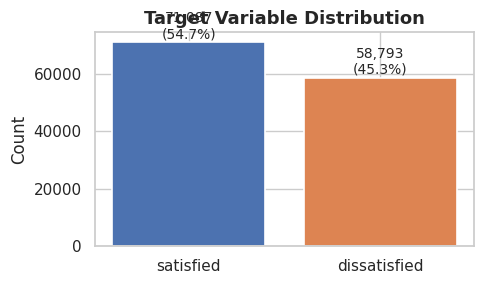

In [5]:
# Visualise target distribution
fig, ax = plt.subplots(figsize=(5, 3))
counts = df['satisfaction'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}\n({val/len(df):.1%})', ha='center', va='bottom', fontsize=10)
ax.set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 4. Logistic Regression Assumptions

Before modelling, we verify the key assumptions of binomial logistic regression:

| # | Assumption | How we address it |
|---|---|---|
| 1 | **Binary outcome** | Verified above — two classes only |
| 2 | **Independence of observations** | Each row = one passenger flight; no repeated measures in this dataset |
| 3 | **No multicollinearity** | Check correlation matrix; drop/monitor highly correlated predictors |
| 4 | **Large sample size** | 129,880 rows — well above the recommended 10 events per predictor |
| 5 | **Linear relationship (log-odds)** | Feature scaling applied; ratings treated as continuous |


In [6]:
# ── Assumption 2: Independence ────────────────────────────────────────────────
print("ASSUMPTION 2: Independence of Observations")
print(f"  Total rows: {len(df):,}")
print("  Each row represents one passenger's survey response.")
print("  No panel/time-series structure. ✅ Independence assumed.")


ASSUMPTION 2: Independence of Observations
  Total rows: 129,880
  Each row represents one passenger's survey response.
  No panel/time-series structure. ✅ Independence assumed.


ASSUMPTION 3: Multicollinearity
  Feature pairs with |r| > 0.75:
    Arrival Delay in Minutes  ↔  Departure Delay in Minutes : r = 0.965



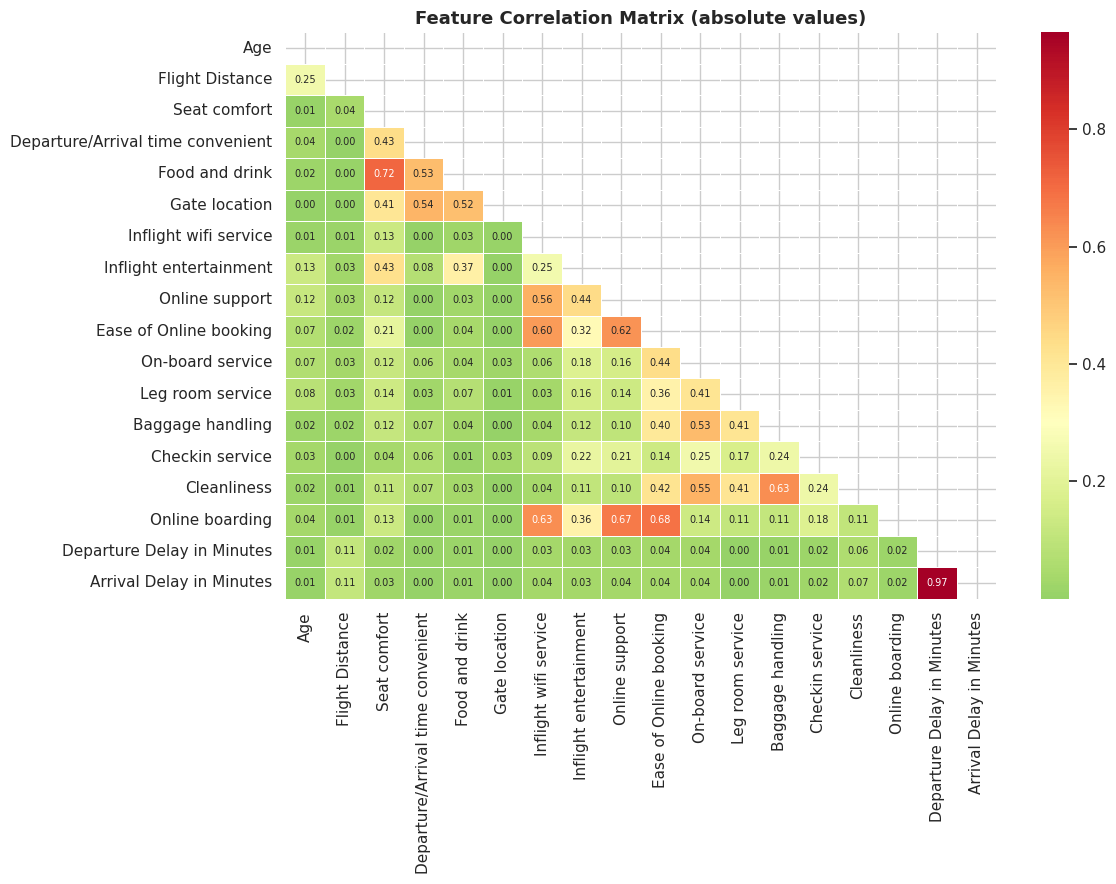

In [7]:
# ── Assumption 3: Multicollinearity check ────────────────────────────────────
numeric_cols = ['Age', 'Flight Distance',
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
    'Gate location', 'Inflight wifi service', 'Inflight entertainment',
    'Online support', 'Ease of Online booking', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service',
    'Cleanliness', 'Online boarding',
    'Departure Delay in Minutes', 'Arrival Delay in Minutes']

corr = df[numeric_cols].corr().abs()
high_corr = [(r, c, corr.loc[r, c])
             for r in corr.index for c in corr.columns
             if r < c and corr.loc[r, c] > 0.75]

print("ASSUMPTION 3: Multicollinearity")
print(f"  Feature pairs with |r| > 0.75:")
if high_corr:
    for r, c, v in high_corr:
        print(f"    {r}  ↔  {c} : r = {v:.3f}")
else:
    print("    None found.")
print()

# Visualise correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn_r', center=0.3,
            annot=True, fmt='.2f', linewidths=0.4,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (absolute values)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
# ── Assumption 4: Sample size rule-of-thumb ──────────────────────────────────
n_features = 23  # total features we will use
min_recommended = n_features * 10
print("ASSUMPTION 4: Sample Size")
print(f"  Features: {n_features}")
print(f"  Minimum recommended (10 per feature): {min_recommended:,}")
print(f"  Actual training rows (~80%): {int(len(df)*0.8):,}")
print(f"  ✅ Sample size is {int(len(df)*0.8) // min_recommended}x the minimum requirement.")


ASSUMPTION 4: Sample Size
  Features: 23
  Minimum recommended (10 per feature): 230
  Actual training rows (~80%): 103,904
  ✅ Sample size is 451x the minimum requirement.


## 5. Visualising Predictors Against the Outcome

We examine how key predictors relate to the binary outcome — an important exploratory step before fitting the model.


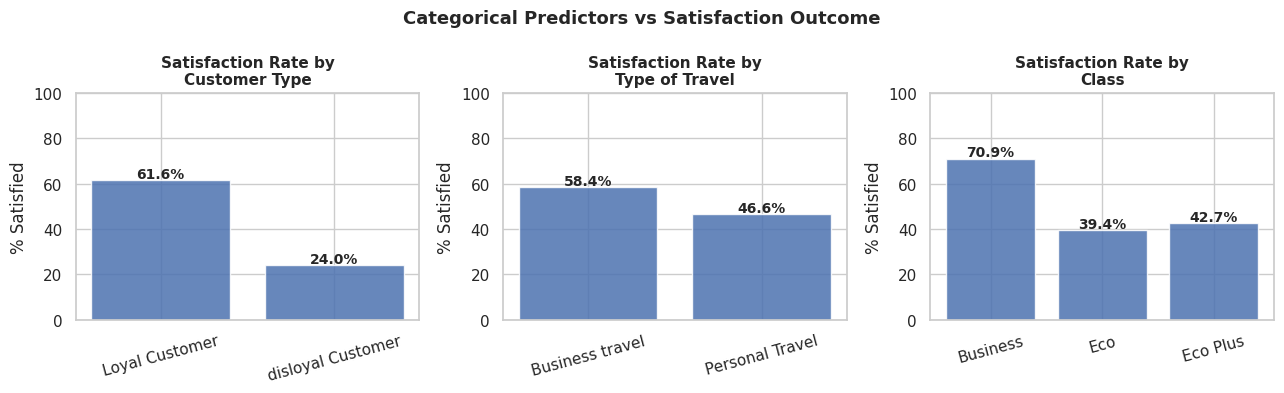

In [9]:
# Satisfaction rate by key categorical predictors
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, ['Customer Type', 'Type of Travel', 'Class']):
    sat = df.groupby(col)['satisfaction'].apply(lambda x: (x=='satisfied').mean()) * 100
    bars = ax.bar(sat.index, sat.values, color='#4C72B0', edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, sat.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Satisfaction Rate by\n{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('% Satisfied'); ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Categorical Predictors vs Satisfaction Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


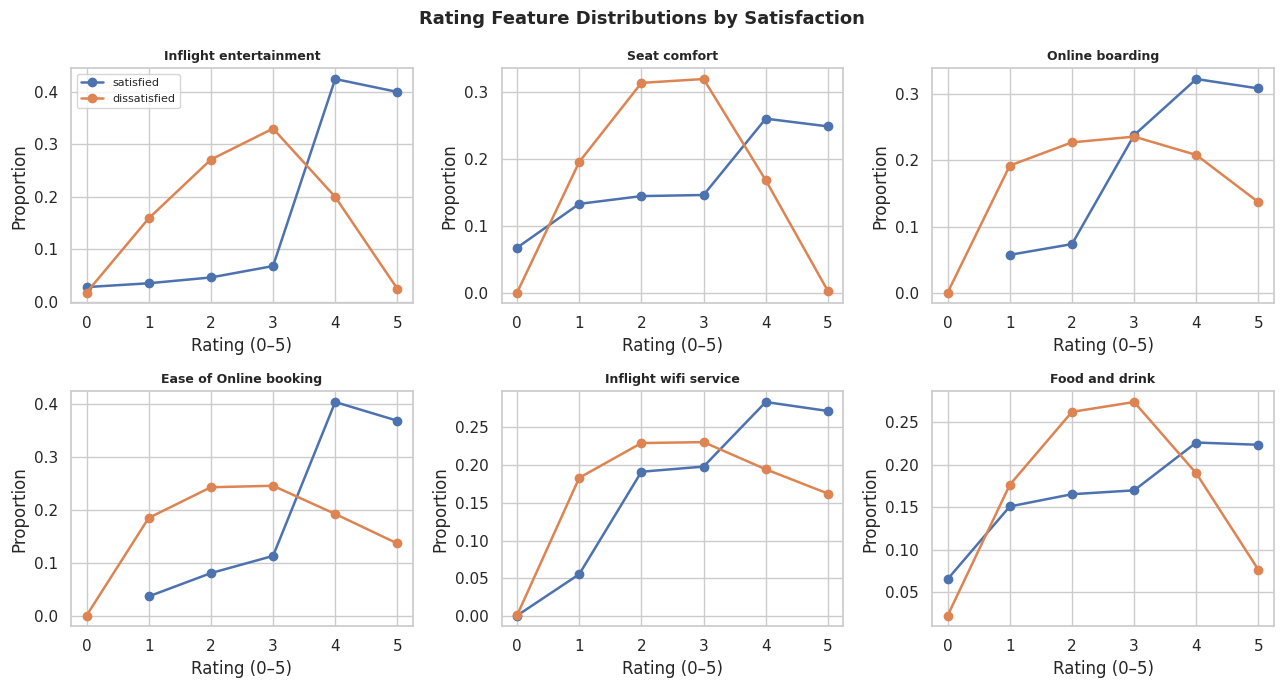

In [10]:
# Rating distributions: satisfied vs dissatisfied
rating_cols = ['Inflight entertainment', 'Seat comfort', 'Online boarding',
               'Ease of Online booking', 'Inflight wifi service', 'Food and drink']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, col in zip(axes, rating_cols):
    for label, color in [('satisfied', '#4C72B0'), ('dissatisfied', '#DD8452')]:
        vals = df[df['satisfaction']==label][col].value_counts().sort_index()
        ax.plot(vals.index, vals.values / vals.sum(), marker='o',
                label=label, color=color, lw=1.8)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Rating (0–5)'); ax.set_ylabel('Proportion')

axes[0].legend(fontsize=8)
fig.suptitle('Rating Feature Distributions by Satisfaction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Data Preparation & Feature Encoding

### Encoding strategy

| Feature | Type | Encoding |
|---|---|---|
| `satisfaction` | Target | `satisfied = 1`, `dissatisfied = 0` |
| `Customer Type` | Binary nominal | `Loyal Customer = 1`, else `0` |
| `Type of Travel` | Binary nominal | `Business travel = 1`, else `0` |
| `Class` | 3-level nominal | One-hot encoding (3 dummy columns) |
| Rating columns (0–5) | Ordinal integer | Used as-is — treated as continuous |
| `Arrival Delay in Minutes` | Numeric, 393 NaN | **Median imputation** (robust to right-skewed delay distribution) |

> **Why median imputation?** Delay distributions are heavily right-skewed. The median (0 min) is more representative than the mean and is not distorted by outlier delays.


In [11]:
# ── Impute missing values ─────────────────────────────────────────────────────
print(f"Missing before imputation: {df['Arrival Delay in Minutes'].isnull().sum()}")
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)
print(f"Missing after imputation:  {df['Arrival Delay in Minutes'].isnull().sum()}")

# ── Encode binary target ──────────────────────────────────────────────────────
df['target'] = (df['satisfaction'] == 'satisfied').astype(int)
print(f"\nTarget encoded: satisfied=1, dissatisfied=0")
print(df['target'].value_counts())


Missing before imputation: 393
Missing after imputation:  0

Target encoded: satisfied=1, dissatisfied=0
target
1    71087
0    58793
Name: count, dtype: int64


In [12]:
# ── Encode categorical predictors ────────────────────────────────────────────
df['Customer Type Enc'] = (df['Customer Type'] == 'Loyal Customer').astype(int)
df['Travel Type Enc']   = (df['Type of Travel'] == 'Business travel').astype(int)

# One-hot encode Class (keep all 3 for full interpretability)
df_class = pd.get_dummies(df['Class'], prefix='Class')
df = pd.concat([df, df_class], axis=1)

feature_cols = [
    'Customer Type Enc', 'Age', 'Travel Type Enc',
    'Class_Business', 'Class_Eco', 'Class_Eco Plus',
    'Flight Distance',
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
    'Gate location', 'Inflight wifi service', 'Inflight entertainment',
    'Online support', 'Ease of Online booking', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service',
    'Cleanliness', 'Online boarding',
    'Departure Delay in Minutes', 'Arrival Delay in Minutes'
]

X = df[feature_cols]
y = df['target']

print(f"Feature matrix shape: {X.shape}")
print(f"\nFeature list:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")


Feature matrix shape: (129880, 23)

Feature list:
   1. Customer Type Enc
   2. Age
   3. Travel Type Enc
   4. Class_Business
   5. Class_Eco
   6. Class_Eco Plus
   7. Flight Distance
   8. Seat comfort
   9. Departure/Arrival time convenient
  10. Food and drink
  11. Gate location
  12. Inflight wifi service
  13. Inflight entertainment
  14. Online support
  15. Ease of Online booking
  16. On-board service
  17. Leg room service
  18. Baggage handling
  19. Checkin service
  20. Cleanliness
  21. Online boarding
  22. Departure Delay in Minutes
  23. Arrival Delay in Minutes


## 7. Train / Test Split

We use an **80/20 stratified split** to preserve class proportions in both sets.
Stratification ensures the model is evaluated on a representative sample of both classes.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserve class balance
)

print(f"Training set : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X):.0%})")
print(f"Test set     : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X):.0%})")
print(f"\nTrain target balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  target balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")


Training set : 103,904 rows  (80%)
Test set     : 25,976 rows  (20%)

Train target balance: {1: 0.547, 0: 0.453}
Test  target balance: {1: 0.547, 0: 0.453}


## 8. Logistic Regression Model

We use a **Pipeline** chaining `StandardScaler → LogisticRegression`.

**Why scale?** Logistic regression uses gradient descent internally. Features on different scales (e.g. `Flight Distance` 0–10,000 vs. ratings 0–5) would cause the optimiser to converge slowly or produce coefficients that cannot be compared directly. Scaling puts all features on the same z-score scale.

**Regularisation:** Default L2 penalty (`C=1.0`) prevents overfitting. With 103K training rows and only 23 features this is a conservative choice.


In [14]:
# Build and fit the pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'))
])

lr_pipeline.fit(X_train, y_train)

print("Model fitted successfully.")
print(f"  Solver        : {lr_pipeline.named_steps['model'].solver}")
print(f"  Penalty       : {lr_pipeline.named_steps['model'].penalty}")
print(f"  C (inv reg.)  : {lr_pipeline.named_steps['model'].C}")
print(f"  Iterations    : {lr_pipeline.named_steps['model'].n_iter_[0]}")
print(f"  Intercept     : {lr_pipeline.named_steps['model'].intercept_[0]:.4f}")


Model fitted successfully.
  Solver        : lbfgs
  Penalty       : deprecated
  C (inv reg.)  : 1.0
  Iterations    : 18
  Intercept     : 0.3446


## 9. Model Coefficients & Intercept

Each coefficient represents the **change in log-odds** of satisfaction for a one-standard-deviation increase in that feature (since features are scaled).

- **Positive coefficient** → feature increases probability of satisfaction  
- **Negative coefficient** → feature decreases probability of satisfaction  
- **Odds Ratio = exp(coefficient)** → multiplicative effect on the odds of satisfaction

The **intercept** represents the log-odds of satisfaction when all features are at their mean values.


In [15]:
coef = lr_pipeline.named_steps['model'].coef_[0]
intercept = lr_pipeline.named_steps['model'].intercept_[0]

coef_df = pd.DataFrame({
    'Feature':     feature_cols,
    'Coefficient': coef,
    'Odds Ratio':  np.exp(coef)
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print(f"Intercept: {intercept:.4f}  (log-odds at mean feature values)")
print()
print("Full coefficient table (sorted by coefficient):")
print(coef_df.round(4).to_string(index=False))


Intercept: 0.3446  (log-odds at mean feature values)

Full coefficient table (sorted by coefficient):
                          Feature  Coefficient  Odds Ratio
           Inflight entertainment       0.9730      2.6458
                Customer Type Enc       0.7250      2.0648
                     Seat comfort       0.3918      1.4796
                 On-board service       0.3875      1.4733
                  Checkin service       0.3553      1.4267
                  Travel Type Enc       0.3508      1.4203
           Ease of Online booking       0.3332      1.3955
                 Leg room service       0.3089      1.3619
                   Class_Business       0.2015      1.2232
                  Online boarding       0.1815      1.1990
                    Gate location       0.1619      1.1757
                   Online support       0.1451      1.1561
                 Baggage handling       0.1094      1.1156
       Departure Delay in Minutes       0.0724      1.0751
             

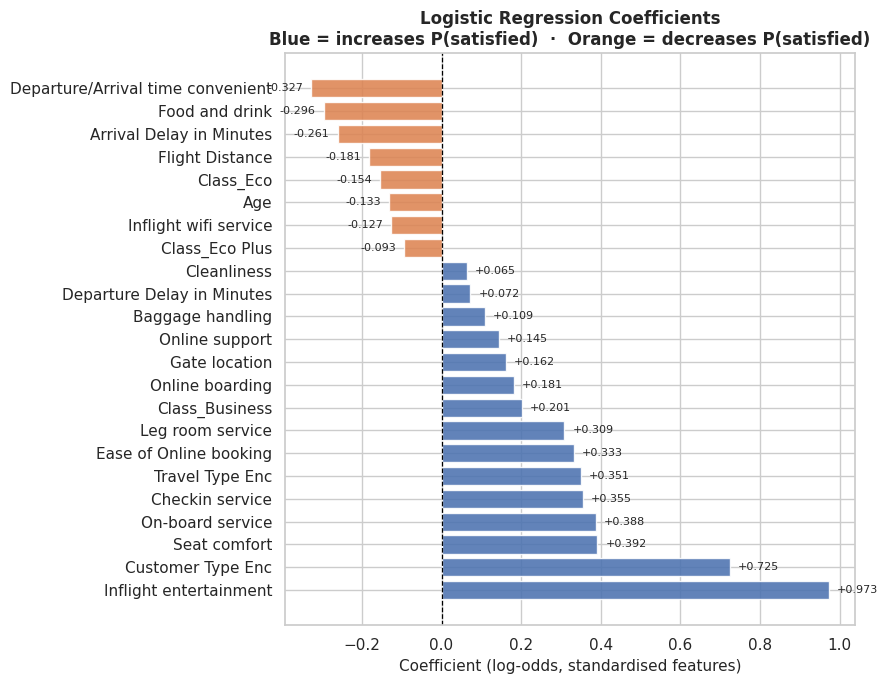

In [16]:
# Visualise coefficients
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#4C72B0' if c > 0 else '#DD8452' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=colors, edgecolor='white', alpha=0.88)
ax.axvline(0, color='black', lw=0.9, linestyle='--')

for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)

ax.set_xlabel('Coefficient (log-odds, standardised features)', fontsize=11)
ax.set_title('Logistic Regression Coefficients\nBlue = increases P(satisfied)  ·  Orange = decreases P(satisfied)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [17]:
# Interpret top positive and negative drivers
print("TOP 5 POSITIVE DRIVERS (increase P(satisfied)):")
print(coef_df.nlargest(5, 'Coefficient')[['Feature','Coefficient','Odds Ratio']].to_string(index=False))

print()
print("TOP 5 NEGATIVE DRIVERS (decrease P(satisfied)):")
print(coef_df.nsmallest(5, 'Coefficient')[['Feature','Coefficient','Odds Ratio']].to_string(index=False))

print()
print("INTERPRETATION GUIDE:")
print("  Odds Ratio > 1.0 → feature increases odds of satisfaction")
print("  Odds Ratio < 1.0 → feature decreases odds of satisfaction")
print("  Example: Inflight entertainment OR =", round(coef_df.loc[coef_df['Feature']=='Inflight entertainment','Odds Ratio'].values[0],3))
print("  → A 1-SD increase in entertainment rating multiplies the odds of satisfaction by that factor.")


TOP 5 POSITIVE DRIVERS (increase P(satisfied)):
               Feature  Coefficient  Odds Ratio
Inflight entertainment     0.972956    2.645753
     Customer Type Enc     0.725040    2.064815
          Seat comfort     0.391791    1.479628
      On-board service     0.387523    1.473326
       Checkin service     0.355350    1.426679

TOP 5 NEGATIVE DRIVERS (decrease P(satisfied)):
                          Feature  Coefficient  Odds Ratio
Departure/Arrival time convenient    -0.327383    0.720808
                   Food and drink    -0.296081    0.743727
         Arrival Delay in Minutes    -0.261238    0.770097
                  Flight Distance    -0.181021    0.834418
                        Class_Eco    -0.153750    0.857486

INTERPRETATION GUIDE:
  Odds Ratio > 1.0 → feature increases odds of satisfaction
  Odds Ratio < 1.0 → feature decreases odds of satisfaction
  Example: Inflight entertainment OR = 2.646
  → A 1-SD increase in entertainment rating multiplies the odds of satisf

## 10. Generate Predictions on Test Set

In [18]:
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]  # P(satisfied)

print(f"Predicted classes shape : {y_pred.shape}")
print(f"Predicted probabilities shape: {y_prob.shape}")
print(f"\nSample probabilities (first 10): {y_prob[:10].round(3)}")
print(f"Sample predictions  (first 10): {y_pred[:10]}")


Predicted classes shape : (25976,)
Predicted probabilities shape: (25976,)

Sample probabilities (first 10): [0.814 0.732 0.042 0.974 0.21  0.375 0.515 0.102 0.109 0.397]
Sample predictions  (first 10): [1 1 0 1 0 0 1 0 0 0]


## 11. Confusion Matrix

The confusion matrix shows the breakdown of correct and incorrect predictions across both classes.

| | Predicted Dissatisfied | Predicted Satisfied |
|---|---|---|
| **Actual Dissatisfied** | True Negative (TN) | False Positive (FP) |
| **Actual Satisfied** | False Negative (FN) | True Positive (TP) |


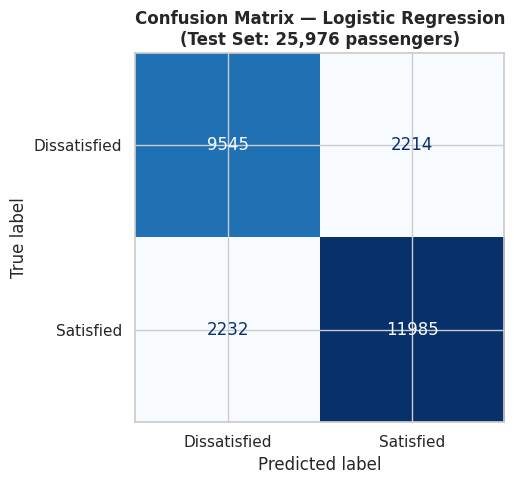

True  Negatives  (correctly predicted dissatisfied) : 9,545
False Positives  (predicted satisfied, actually not): 2,214
False Negatives  (predicted dissatisfied, actually) : 2,232
True  Positives  (correctly predicted satisfied)    : 11,985


In [19]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Dissatisfied', 'Satisfied'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression\n(Test Set: 25,976 passengers)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"True  Negatives  (correctly predicted dissatisfied) : {tn:,}")
print(f"False Positives  (predicted satisfied, actually not): {fp:,}")
print(f"False Negatives  (predicted dissatisfied, actually) : {fn:,}")
print(f"True  Positives  (correctly predicted satisfied)    : {tp:,}")


## 12. Classification Metrics — Precision, Recall & Full Report

### Why Precision and Recall matter more than Accuracy

| Metric | Formula | Business meaning |
|---|---|---|
| **Accuracy** | (TP+TN) / Total | % of all predictions correct — can mislead with imbalanced classes |
| **Precision** | TP / (TP+FP) | Of passengers predicted satisfied, how many actually were? |
| **Recall** | TP / (TP+FN) | Of all actually satisfied passengers, how many did we catch? |
| **F1** | 2×P×R / (P+R) | Harmonic mean — balances precision and recall |

For airlines, **Recall** is critical: a False Negative means a dissatisfied passenger goes undetected and receives no intervention.


In [20]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc:.2%})")
print(f"  Precision : {prec:.4f}  ({prec:.2%})")
print(f"  Recall    : {rec:.4f}  ({rec:.2%})")
print(f"  ROC-AUC   : {auc:.4f}  ({auc:.2%})")
print("=" * 45)
print()
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Dissatisfied', 'Satisfied']))


  Accuracy  : 0.8288  (82.88%)
  Precision : 0.8441  (84.41%)
  Recall    : 0.8430  (84.30%)
  ROC-AUC   : 0.9035  (90.35%)

Full Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.81      0.81      0.81     11759
   Satisfied       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



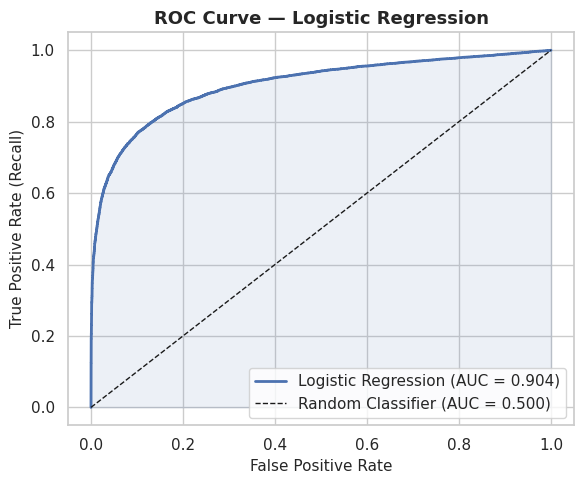

In [21]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#4C72B0', lw=2,
        label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve — Logistic Regression', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 13. Business Recommendations

Based on the Logistic Regression coefficients, here are data-backed recommendations:

### 🎬 1. Inflight Entertainment (coeff = +0.973, OR = 2.65)
The single largest positive driver. A 1-SD improvement in entertainment rating **2.65× the odds** of satisfaction.  
**Action:** Upgrade content libraries and enable personal device streaming on economy routes.

### 🙋 2. Customer Loyalty (coeff = +0.725, OR = 2.06)
Loyal customers are **2× more likely** to be satisfied than disloyal customers.  
**Action:** Fast-track loyalty tier upgrades; proactive status match campaigns for high-frequency economy passengers.

### 💺 3. On-board Service & Seat Comfort (coeff ≈ +0.39)
Both features carry similar weight, confirmed by near-identical coefficients.  
**Action:** Crew training programmes + seat reconfiguration on medium-haul economy routes.

### ⏰ 4. Departure/Arrival Timing (coeff = −0.327, OR = 0.72)
Inconvenient scheduling reduces odds of satisfaction by 28%.  
**Action:** Schedule audit on leisure routes; improve gate change communications.

### 🍽️ 5. Food & Drink (coeff = −0.296, OR = 0.74)
Acts as a dissatisfier — poor F&B penalises satisfaction more than good F&B rewards it.  
**Action:** Menu audit to remove bottom-rated items before investing in premium additions.

---

## 14. Limitations & Next Steps

| Limitation | Next Step |
|---|---|
| Linear decision boundary — cannot capture feature interactions | Try Random Forest or XGBoost |
| Likert ratings are self-reported — subject to recency bias | Supplement with operational data |
| Fixed 0.5 threshold | Tune threshold based on intervention cost vs. churn value |
| Static training snapshot | Retrain quarterly as satisfaction drivers shift seasonally |

### Deployment Path
```python
import joblib
joblib.dump(lr_pipeline, 'logistic_regression_model.pkl')
# → FastAPI endpoint → POST /predict → return P(satisfied)
# → Score passengers within 24h of landing → trigger retention offers
```
